# AI Reliability Platform — Building `evaluate_answer()`
### (Core of the "Evaluation Pipeline" component — AI Doctor Capstone Project)

This notebook builds the **first and most important building block** of the AI Reliability
Platform: a function that takes a question, a generated answer, and the retrieved contexts
(from a RAG pipeline), and evaluates how **faithful** the answer is to those contexts and
how likely it is to contain a **hallucination**.

**Why start here?** Every other component of the platform (Root Cause Analysis, Recommendation
Engine, Drift Detection, Dashboard...) depends on having a working evaluator first. Without
this, there is nothing to analyze, monitor, or improve.

**Approach used:** *LLM-as-a-Judge*. Instead of training a custom ML model from scratch (which
would need a large labeled dataset we don't have), we use a strong LLM (Claude) as an impartial
judge that scores each answer against its source contexts. This is the standard, practical
approach used by real RAG-evaluation tools (RAGAS, DeepEval) and is realistic to build within
a 3-week Capstone timeline.

**Workflow in this notebook:**
1. Sample data (simulated RAG question/answer/context sets — some correct, some hallucinated)
2. Preprocessing (prompt template for the judge)
3. Building `evaluate_answer()`
4. Evaluation (running it on the sample set + visualizing results)
5. Tuning suggestions (how to make the judge more reliable)


## 1. Setup

In [1]:
import os
import json
import re
from dataclasses import dataclass, asdict
from typing import List

import pandas as pd
import matplotlib.pyplot as plt

# The Anthropic SDK is used to call Claude as the "judge" model.
# An API key is required in production — NEVER hardcode it in code.
# Set it as an environment variable before running this notebook:
#     export ANTHROPIC_API_KEY="your-key-here"
import anthropic

API_KEY = os.environ.get("ANTHROPIC_API_KEY")
MODEL_NAME = "claude-sonnet-5"  # good balance of quality/cost for evaluation tasks

if API_KEY:
    client = anthropic.Anthropic(api_key=API_KEY)
    print("Anthropic client ready — will call the real Claude API.")
else:
    client = None
    print("No ANTHROPIC_API_KEY found in the environment.")
    print("This notebook will fall back to a MOCK judge so you can still see the")
    print("full pipeline run end-to-end. Set your real key to get real evaluations.")


No ANTHROPIC_API_KEY found in the environment.
This notebook will fall back to a MOCK judge so you can still see the
full pipeline run end-to-end. Set your real key to get real evaluations.


## 2. Sample Data

In a real deployment, `(question, answer, contexts)` triples would come from your RAG
system's logs. Here we hand-build a small, clearly labeled set: some answers are faithful
to their context, some contain a subtle hallucination, and one has no relevant context at
all. This lets us sanity-check that the evaluator actually distinguishes good from bad
answers before wiring it into the FastAPI service you already have (`main.py`).


In [2]:
samples = [
    {
        "id": "sample_1_faithful",
        "question": "What is the capital of France?",
        "contexts": ["Paris is the capital and most populous city of France."],
        "answer": "The capital of France is Paris.",
        "expected_label": "faithful",
    },
    {
        "id": "sample_2_hallucination",
        "question": "What is the capital of France?",
        "contexts": ["Paris is the capital and most populous city of France."],
        "answer": "The capital of France is Paris, which has a population of over 50 million people.",
        "expected_label": "hallucination",  # the population figure is fabricated
    },
    {
        "id": "sample_3_faithful",
        "question": "When was the FastAPI framework first released?",
        "contexts": ["FastAPI is a modern Python web framework created by Sebastian Ramirez, first released in December 2018."],
        "answer": "FastAPI was first released in December 2018.",
        "expected_label": "faithful",
    },
    {
        "id": "sample_4_unsupported",
        "question": "Who created the FastAPI framework?",
        "contexts": ["Docker is a platform for developing, shipping, and running applications in containers."],
        "answer": "FastAPI was created by Guido van Rossum in 2015.",
        "expected_label": "hallucination",  # context is irrelevant, answer is fabricated
    },
    {
        "id": "sample_5_faithful",
        "question": "What does RAG stand for in the context of LLMs?",
        "contexts": ["RAG (Retrieval-Augmented Generation) combines a retrieval step over a document store with an LLM generation step to ground answers in real data."],
        "answer": "RAG stands for Retrieval-Augmented Generation, a technique that grounds LLM answers in retrieved documents.",
        "expected_label": "faithful",
    },
]

pd.DataFrame(samples)[["id", "question", "answer", "expected_label"]]


,id,question,answer,expected_label
0,sample_1_faithful,What is the capital of France?,The capital of France is Paris.,faithful
1,sample_2_hallucination,What is the capital of France?,"The capital of France is Paris, which has a po...",hallucination
2,sample_3_faithful,When was the FastAPI framework first released?,FastAPI was first released in December 2018.,faithful
3,sample_4_unsupported,Who created the FastAPI framework?,FastAPI was created by Guido van Rossum in 2015.,hallucination
4,sample_5_faithful,What does RAG stand for in the context of LLMs?,"RAG stands for Retrieval-Augmented Generation,...",faithful


## 3. Preprocessing — the Judge Prompt

This is the "preprocessing" step for an LLM-as-a-judge pipeline: instead of scaling numeric
features, we carefully engineer the **prompt** the judge model will see. A good judge prompt:
- Clearly separates the *context* (source of truth) from the *answer* being graded
- Forces **structured output** (JSON) so we can parse scores programmatically
- Asks for a short explanation, which is critical later for Root Cause Analysis


In [3]:
JUDGE_SYSTEM_PROMPT = """You are a strict evaluation engine for a Retrieval-Augmented \
Generation (RAG) system. You will be given a QUESTION, the CONTEXTS that were retrieved for \
it, and the ANSWER that the AI system produced. Your job is to evaluate the answer, not to \
answer the question yourself.

Score the answer on:
- correctness_score (0.0-1.0): does the answer correctly address the question?
- faithfulness_score (0.0-1.0): is every claim in the answer actually supported by the \
  contexts? Penalize any fact not present in the contexts, even if it happens to be true \
  in the real world.
- hallucination_risk (0.0-1.0): how likely is the answer to contain fabricated information \
  not grounded in the contexts? (0 = no risk, 1 = certainly hallucinated)

Then assign an overall status: "pass" (faithfulness_score >= 0.7 and hallucination_risk <= \
0.3), "warning" (borderline), or "fail" (clear hallucination or unfaithful answer).

Respond with ONLY valid JSON in this exact shape, no extra text:
{
  "correctness_score": <float>,
  "faithfulness_score": <float>,
  "hallucination_risk": <float>,
  "status": "<pass|warning|fail>",
  "explanation": "<one or two sentence explanation citing what was/wasn't supported>"
}
"""

def build_judge_message(question: str, contexts: List[str], answer: str) -> str:
    context_block = "\n".join(f"- {c}" for c in contexts) if contexts else "(no contexts retrieved)"
    return (
        f"QUESTION:\n{question}\n\n"
        f"CONTEXTS:\n{context_block}\n\n"
        f"ANSWER:\n{answer}\n\n"
        "Evaluate this answer now."
    )

print(build_judge_message(**{k: samples[1][k] for k in ('question', 'contexts', 'answer')}))


QUESTION:
What is the capital of France?

CONTEXTS:
- Paris is the capital and most populous city of France.

ANSWER:
The capital of France is Paris, which has a population of over 50 million people.

Evaluate this answer now.


## 4. Building `evaluate_answer()`

This is the function that will plug directly into the `create_health_check()` endpoint you
already wrote in `main.py`. It:
1. Sends the judge prompt to Claude
2. Parses the JSON response into a typed `EvaluationResult`
3. Falls back to a simple **mock judge** (rule-based, using word overlap) if no API key is
   set, so the notebook — and your understanding of the pipeline — still works end-to-end
   without requiring a paid API call. Swap in the real client for production use.


In [4]:
@dataclass
class EvaluationResult:
    correctness_score: float
    faithfulness_score: float
    hallucination_risk: float
    status: str
    explanation: str


def _extract_json(text: str) -> dict:
    """Judges sometimes wrap JSON in prose or code fences — pull the JSON block out safely."""
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in judge response: {text!r}")
    return json.loads(match.group(0))


def _mock_judge(question: str, contexts: List[str], answer: str) -> dict:
    """A crude stand-in for the LLM judge, used only when no API key is available.
    Real projects should NOT ship this — it's here purely so the notebook runs offline.
    It approximates faithfulness using simple word overlap between the answer and contexts.
    """
    context_words = set(" ".join(contexts).lower().split())
    answer_words = set(answer.lower().split())
    overlap = len(answer_words & context_words) / max(len(answer_words), 1)

    faithfulness = round(min(1.0, overlap * 1.4), 2)
    hallucination_risk = round(1 - faithfulness, 2)
    correctness = faithfulness  # crude proxy for this mock only

    if faithfulness >= 0.7 and hallucination_risk <= 0.3:
        status = "pass"
    elif faithfulness >= 0.4:
        status = "warning"
    else:
        status = "fail"

    return {
        "correctness_score": correctness,
        "faithfulness_score": faithfulness,
        "hallucination_risk": hallucination_risk,
        "status": status,
        "explanation": (
            f"[MOCK JUDGE] Word overlap between answer and contexts was {overlap:.2f}. "
            "Replace with the real Claude judge for reliable results."
        ),
    }


def evaluate_answer(question: str, contexts: List[str], answer: str,
                     reference_answer: str = None) -> EvaluationResult:
    """Evaluate a single RAG answer for correctness, faithfulness, and hallucination risk."""
    if client is None:
        raw = _mock_judge(question, contexts, answer)
    else:
        try:
            message = client.messages.create(
                model=MODEL_NAME,
                max_tokens=500,
                system=JUDGE_SYSTEM_PROMPT,
                messages=[{
                    "role": "user",
                    "content": build_judge_message(question, contexts, answer),
                }],
            )
            response_text = message.content[0].text
            raw = _extract_json(response_text)
        except Exception as exc:  # basic error handling around the API call
            raw = {
                "correctness_score": 0.0,
                "faithfulness_score": 0.0,
                "hallucination_risk": 1.0,
                "status": "fail",
                "explanation": f"Evaluator error, treated as fail-safe: {exc}",
            }

    return EvaluationResult(**raw)


# Quick smoke test on one example
test_result = evaluate_answer(**{k: samples[0][k] for k in ('question', 'contexts', 'answer')})
test_result


EvaluationResult(correctness_score=0.93, faithfulness_score=0.93, hallucination_risk=0.07, status='pass', explanation='[MOCK JUDGE] Word overlap between answer and contexts was 0.67. Replace with the real Claude judge for reliable results.')

## 5. Evaluation — Run on the Full Sample Set

Now we run `evaluate_answer()` on every sample and check whether it correctly separates the
`faithful` examples from the `hallucination` examples — this is exactly the kind of sanity
check you should always do before trusting an evaluator inside a larger pipeline.


In [5]:
rows = []
for s in samples:
    result = evaluate_answer(question=s["question"], contexts=s["contexts"], answer=s["answer"])
    rows.append({
        "id": s["id"],
        "expected_label": s["expected_label"],
        **asdict(result),
    })

results_df = pd.DataFrame(rows)
results_df


,id,expected_label,correctness_score,faithfulness_score,hallucination_risk,status,explanation
0,sample_1_faithful,faithful,0.93,0.93,0.07,pass,[MOCK JUDGE] Word overlap between answer and c...
1,sample_2_hallucination,hallucination,0.40,0.40,0.60,warning,[MOCK JUDGE] Word overlap between answer and c...
2,sample_3_faithful,faithful,1.00,1.00,0.00,pass,[MOCK JUDGE] Word overlap between answer and c...
3,sample_4_unsupported,hallucination,0.16,0.16,0.84,fail,[MOCK JUDGE] Word overlap between answer and c...
4,sample_5_faithful,faithful,0.50,0.50,0.50,warning,[MOCK JUDGE] Word overlap between answer and c...


/tmp/ipykernel_567/4238944605.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["id"], rotation=30, ha="right")


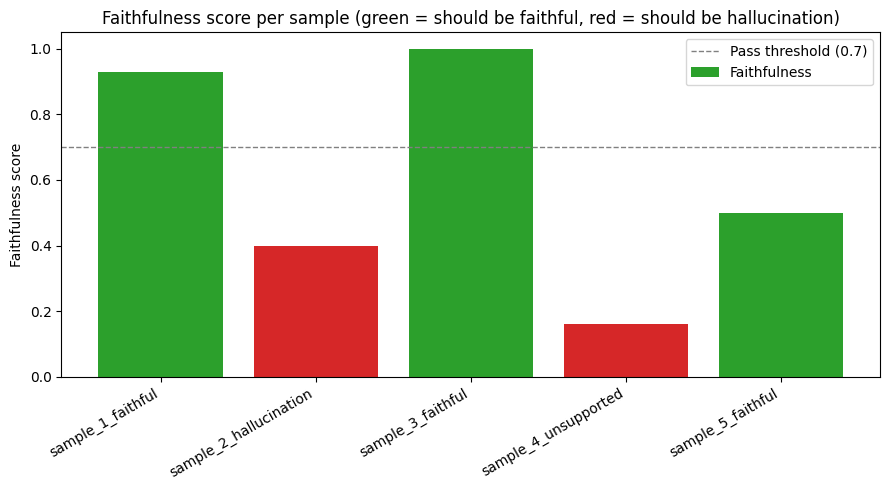

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = results_df["expected_label"].map({"faithful": "#2ca02c", "hallucination": "#d62728"})
ax.bar(results_df["id"], results_df["faithfulness_score"], color=colors, label="Faithfulness")
ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, label="Pass threshold (0.7)")
ax.set_ylabel("Faithfulness score")
ax.set_ylim(0, 1.05)
ax.set_title("Faithfulness score per sample (green = should be faithful, red = should be hallucination)")
ax.set_xticklabels(results_df["id"], rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


**How to read this chart:** a well-calibrated evaluator should score the green (faithful)
bars above the 0.7 pass line, and the red (hallucination) bars below it. If you're running
with the real Claude judge, you should see a clean separation. If you're running the mock
judge, the separation will be rougher — that's expected, and exactly why the mock is not
meant for production.


## 6. Tuning Suggestions — Next Steps for a More Reliable Judge

The evaluator above is a solid first version. To make it more robust for your Capstone
submission, consider these concrete upgrades (roughly in priority order):

1. **Few-shot calibration** — add 2-3 example (question, context, answer, correct score)
   triples directly into `JUDGE_SYSTEM_PROMPT` so the judge has a concrete reference point,
   instead of relying purely on its own judgment.
2. **Self-consistency** — call `evaluate_answer()` 2-3 times per sample with a non-zero
   `temperature` and average the scores, or take the majority `status`. This reduces
   noise from any single call.
3. **Dual-judge cross-check** — run a second, different model (e.g. GPT or Gemini, tying
   into your "Model Comparison" component) on the same input and flag cases where the two
   judges disagree strongly — those are your highest-value cases for manual review.
4. **Structured output validation** — use `pydantic` to validate the judge's JSON against
   a schema and automatically retry once if parsing fails, instead of only wrapping in
   `try/except`.
5. **Track judge accuracy over time** — once you have real human-labeled examples, treat
   the judge itself as a classifier and report its precision/recall against those labels.
   This closes the loop back into the "Drift Detection" component: if judge accuracy drops,
   the prompt likely needs recalibration.

### Immediate next step for the project
Wire `evaluate_answer()` (as written above) directly into `create_health_check()` in your
existing `main.py` — the return shape already matches what that endpoint expects
(`correctness_score`, `faithfulness_score`, `hallucination_risk`, `status`, `explanation`).
